In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds

IMG_SIZE = 224
NUM_CLASSES = 102
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE


def preprocess(image, label):
    image = tf.image.resize_with_pad(image, IMG_SIZE, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label

def preprocess_vit_inference(image, label):
    image = tf.image.resize_with_pad(image, IMG_SIZE, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def one_hot(image, label):
    label = tf.one_hot(label, NUM_CLASSES)
    return image, label


dataset, info = tfds.load(
    "oxford_flowers102",
    with_info=True,
    as_supervised=True
)

test_ds_raw = dataset["test"].map(preprocess, num_parallel_calls=AUTOTUNE)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_flowers102/incomplete.88DH3Y_2.1.1/oxford_flowers102-test.tfrecord-…

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_flowers102/incomplete.88DH3Y_2.1.1/oxford_flowers102-validation.tfr…

Dataset oxford_flowers102 downloaded and prepared to /root/tensorflow_datasets/oxford_flowers102/2.1.1. Subsequent calls will reuse this data.


In [ ]:
import tensorflow as tf

def select_first_n_per_class(ds, n=20, num_classes=102):
    counts = {i: 0 for i in range(num_classes)}
    selected_images = []
    selected_labels = []

    for image, label in tfds.as_numpy(ds):
        label_int = int(label)
        if counts[label_int] < n:
            selected_images.append(image)
            selected_labels.append(label_int)
            counts[label_int] += 1

        if all(v >= n for v in counts.values()):
            break

    images = tf.convert_to_tensor(selected_images, dtype=tf.float32)
    labels = tf.convert_to_tensor(selected_labels, dtype=tf.int32)

    return tf.data.Dataset.from_tensor_slices((images, labels))

test_ds_20_raw = select_first_n_per_class(test_ds_raw, n=20)

In [ ]:
cnn = tf.keras.models.load_model("/content/drive/MyDrive/PSI5790/efficientnetb0_flowers.keras")
vit = tf.keras.models.load_model("/content/drive/MyDrive/PSI5790/deit_tiny_flowers.keras")
best = tf.keras.models.load_model("/content/drive/MyDrive/PSI5790/best_flowers102_efficientnetv2b3.keras")


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 46 variables whereas the saved optimizer has 50 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
def central_occlusion(image, label, frac=0.35):
    h = tf.shape(image)[0]
    w = tf.shape(image)[1]

    occ_h = tf.cast(tf.cast(h, tf.float32) * frac, tf.int32)
    occ_w = tf.cast(tf.cast(w, tf.float32) * frac, tf.int32)

    y0 = (h - occ_h) // 2
    x0 = (w - occ_w) // 2

    mask = tf.ones_like(image)

    zeros = tf.zeros((occ_h, occ_w, 3), dtype=image.dtype)
    paddings = [
        [y0, h - y0 - occ_h],
        [x0, w - x0 - occ_w],
        [0, 0]
    ]

    occ_mask = tf.pad(zeros, paddings, constant_values=1.0)
    image_occ = image * occ_mask

    return image_occ, label

In [ ]:
def peripheral_occlusion(image, label, keep_frac=0.55):
    h = tf.shape(image)[0]
    w = tf.shape(image)[1]

    keep_h = tf.cast(tf.cast(h, tf.float32) * keep_frac, tf.int32)
    keep_w = tf.cast(tf.cast(w, tf.float32) * keep_frac, tf.int32)

    y0 = (h - keep_h) // 2
    x0 = (w - keep_w) // 2

    center = tf.ones((keep_h, keep_w, 3), dtype=image.dtype)

    paddings = [
        [y0, h - y0 - keep_h],
        [x0, w - x0 - keep_w],
        [0, 0]
    ]

    mask = tf.pad(center, paddings, constant_values=0.0)
    image_occ = image * mask

    return image_occ, label

In [ ]:
import tensorflow as tf

PATCH_SIZE = 16
IMG_SIZE = 224
NUM_PATCHES_PER_SIDE = IMG_SIZE // PATCH_SIZE  # 14
NUM_PATCHES = NUM_PATCHES_PER_SIDE ** 2        # 196
REMOVE_FRAC = 0.25
NUM_REMOVE = int(NUM_PATCHES * REMOVE_FRAC)    # 49

def random_patch_occlusion(image, label):
    """
    Remove aleatoriamente 25% dos patches 16x16 da imagem.
    A imagem deve estar em shape (224, 224, 3).
    """

    # Sorteia 49 índices entre os 196 patches
    patch_indices = tf.random.shuffle(tf.range(NUM_PATCHES))[:NUM_REMOVE]

    # Cria vetor 1D com 196 posições: 1 = mantém, 0 = remove
    keep = tf.ones((NUM_PATCHES,), dtype=tf.float32)

    updates = tf.zeros((NUM_REMOVE,), dtype=tf.float32)
    keep = tf.tensor_scatter_nd_update(
        keep,
        indices=tf.expand_dims(patch_indices, axis=1),
        updates=updates
    )

    # Transforma em grade 14x14
    keep_grid = tf.reshape(keep, (NUM_PATCHES_PER_SIDE, NUM_PATCHES_PER_SIDE))

    # Expande cada célula da grade para um bloco 16x16
    mask = tf.repeat(keep_grid, PATCH_SIZE, axis=0)
    mask = tf.repeat(mask, PATCH_SIZE, axis=1)

    # Shape (224, 224, 1), para aplicar nos 3 canais
    mask = tf.expand_dims(mask, axis=-1)

    image_occ = image * mask

    return image_occ, label

In [ ]:
def make_eval_dataset(ds_raw, occlusion=None):
    ds = ds_raw

    if occlusion == "central":
        ds = ds.map(lambda x, y: central_occlusion(x, y, frac=0.35),
                    num_parallel_calls=AUTOTUNE)

    elif occlusion == "peripheral":
        ds = ds.map(lambda x, y: peripheral_occlusion(x, y, keep_frac=0.55),
                    num_parallel_calls=AUTOTUNE)

    elif occlusion == "random_patch":
        ds = ds.map(lambda x, y: random_patch_occlusion(x, y),
                    num_parallel_calls=AUTOTUNE)

    ds = (
        ds
        .map(one_hot, num_parallel_calls=AUTOTUNE)
        .batch(BATCH_SIZE)
        .prefetch(AUTOTUNE)
    )

    return ds



In [ ]:
test_clean = make_eval_dataset(test_ds_20_raw, occlusion=None)
test_central = make_eval_dataset(test_ds_20_raw, occlusion="central")
test_random = make_eval_dataset(test_ds_20_raw, occlusion="random_patch")

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf

def plot_first_4(ds, title, images_are_0_255=True):
    images, labels = next(iter(ds))

    images = images[:4]
    labels = labels[:4]

    plt.figure(figsize=(12, 4))

    for i in range(4):
        img = images[i]

        if images_are_0_255:
            img = tf.clip_by_value(img, 0, 255)
            img = tf.cast(img, tf.uint8)
        else:
            img = tf.clip_by_value(img, 0, 1)

        class_id = tf.argmax(labels[i]).numpy()

        plt.subplot(1, 4, i + 1)
        plt.imshow(img)
        plt.title(f"class {class_id}")
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

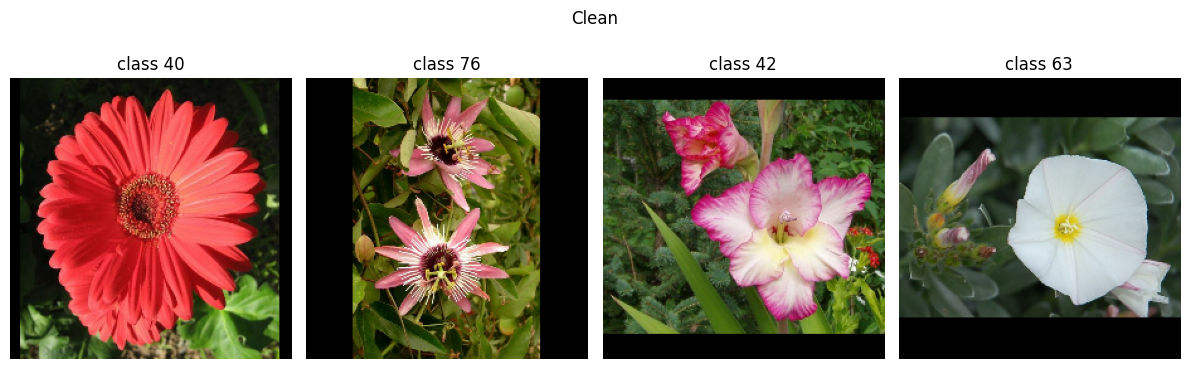

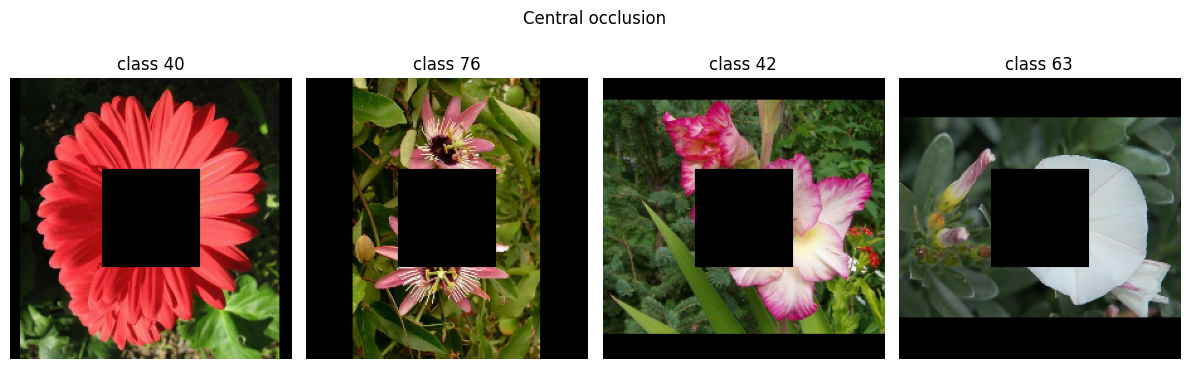

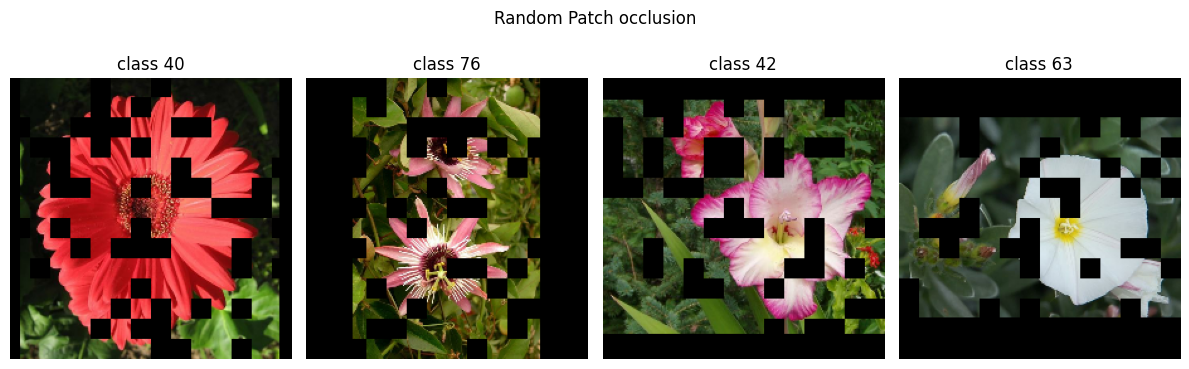

In [ ]:
plot_first_4(test_clean, "Clean", images_are_0_255=True)
plot_first_4(test_central, "Central occlusion", images_are_0_255=True)
plot_first_4(test_random, "Random Patch occlusion", images_are_0_255=True)

In [ ]:
best_clean = best.evaluate(test_clean)
best_central = best.evaluate(test_central)
best_random = best.evaluate(test_random)

64/64 ━━━━━━━━━━━━━━━━━━━━ 28s 177ms/step - accuracy: 0.8368 - loss: 1.1042 - top5_accuracy: 0.9578
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.5873 - loss: 2.0000 - top5_accuracy: 0.8250
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.3765 - loss: 2.8400 - top5_accuracy: 0.6721


In [ ]:
cnn_clean = cnn.evaluate(test_clean)
cnn_central = cnn.evaluate(test_central)
cnn_random = cnn.evaluate(test_random)

64/64 ━━━━━━━━━━━━━━━━━━━━ 165s 2s/step - accuracy: 0.8289 - loss: 0.6313
64/64 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step - accuracy: 0.5328 - loss: 2.0102
64/64 ━━━━━━━━━━━━━━━━━━━━ 158s 2s/step - accuracy: 0.3549 - loss: 2.8027


In [ ]:
test_ds_raw_vit = dataset["test"].map(
    preprocess_vit_inference,
    num_parallel_calls=AUTOTUNE
)

test_ds_20_raw_vit = select_first_n_per_class(test_ds_raw_vit, n=20)

test_clean_vit = make_eval_dataset(test_ds_20_raw_vit, occlusion=None)
test_central_vit = make_eval_dataset(test_ds_20_raw_vit, occlusion="central")
test_random_vit = make_eval_dataset(test_ds_20_raw_vit, occlusion="random_patch")


vit_clean = vit.evaluate(test_clean_vit)
vit_central = vit.evaluate(test_central_vit)
vit_random = vit.evaluate(test_random_vit)

64/64 ━━━━━━━━━━━━━━━━━━━━ 246s 4s/step - accuracy: 0.8196 - loss: 0.7829
64/64 ━━━━━━━━━━━━━━━━━━━━ 237s 4s/step - accuracy: 0.6451 - loss: 1.4452
64/64 ━━━━━━━━━━━━━━━━━━━━ 238s 4s/step - accuracy: 0.7691 - loss: 0.9500
